Question 5 Use the generative nature of GMMs to identify outliers by calculating density.
Task:
1. Fit a GMM to a "clean" version of a dataset (e.g., Old Faithful geyser data).
2. Use the . score_samples() method to compute the weighted log-probabilities for each data point.
3. Define a threshold (e.g., the lowest 4% of densities) and label these points as anomalies.
4. Scatter plot the data, coloring the points by their density value, and use a distinct marker (like a red 'X') for the identified anomalies.

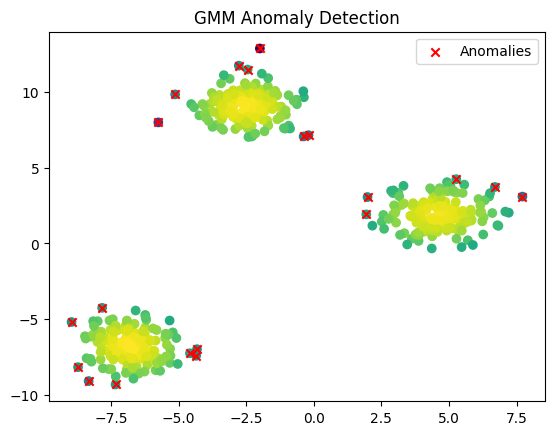

In [7]:
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

# Step 1 — Generate dataset
X, _ = make_blobs(n_samples=500, centers=3, random_state=42)

# Step 2 — Fit GMM
gmm = GaussianMixture(n_components=3)
gmm.fit(X)

# Step 3 — Get log probability of each point
log_probs = gmm.score_samples(X)

# Step 4 — Define anomaly threshold (lowest 4%)
threshold = np.percentile(log_probs, 4)
anomalies = log_probs < threshold

# Step 5 — Plot
plt.scatter(X[:,0], X[:,1], c=log_probs, cmap='viridis')
plt.scatter(X[anomalies,0], X[anomalies,1],
            marker='x', color='red', label='Anomalies')
plt.legend()
plt.title("GMM Anomaly Detection")
plt.show()